# Lagos Apartment Price Prediction

## Project Overview
In this project, I build a machine learning model that predicts apartment prices in **Lagos, Nigeria**. I progress from a simple single-feature linear regression to a full multi-feature pipeline using real scraped property data.

**Project involves:**
- Data wrangling with a reusable `wrangle()` function
- Exploratory data analysis and visualization
- Linear regression, Ridge regression
- Feature encoding (OneHotEncoder) and imputation (SimpleImputer)
- Sklearn Pipelines
- Neighborhood centroid geocoding (engineering lat/lon form town names)
- Interactive prediction dashboard with ipywidgets

**Target variable:** `price` (in Nigerian Naira)

**Dataset:** Nigeria Houses and Prices - Kaggle (https://www.kaggle.com/datasets/abdullahiyunus/nigeria-houses-and-prices-dataset)

## 1. Predicting Price with Property Size

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

### Prepare Data

In [10]:
def wrangle(filepath):
    df = pd.read_csv(filepath)
    
    # Subset to Lagos only
    mask_lagos = df["state"] == "Lagos"
    # Subset to Flats/apartments only
    mask_apt = df["title"] == "Block of Flats"
    # Subset to properties priced below ₦150,000,000 (to focus on mid-market)
    mask_price = df["price"] < 150_000_000
    
    df = df[mask_lagos & mask_apt & mask_price]

    # Remove bedroom outliers
    low, high = df["bedrooms"].quantile([0.1, 0.9])
    mask_bed = df["bedrooms"].between(low, high)
    df = df[mask_bed]
    
    return df

df = wrangle("data/nigeria_houses.csv")
print("df shape:", df.shape)
df.head()

df shape: (769, 8)


,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
42,2.0,2.0,3.0,2.0,Block of Flats,Lekki,Lagos,30000000.0
46,3.0,3.0,4.0,4.0,Block of Flats,Lekki,Lagos,25500000.0
83,2.0,5.0,5.0,4.0,Block of Flats,Ikorodu,Lagos,22500000.0
110,3.0,5.0,5.0,4.0,Block of Flats,Magodo,Lagos,55000000.0
182,3.0,3.0,4.0,4.0,Block of Flats,Ejigbo,Lagos,55000000.0


In [3]:
# Explore data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  float64
 1   bathrooms      24326 non-null  float64
 2   toilets        24326 non-null  float64
 3   parking_space  24326 non-null  float64
 4   title          24326 non-null  object 
 5   town           24326 non-null  object 
 6   state          24326 non-null  object 
 7   price          24326 non-null  float64
dtypes: float64(5), object(3)
memory usage: 1.5+ MB


In [5]:
# Explore unique property types and states
print("Property types:\n", df["title"].value_counts())
print("\nStates:\n", df["state"].value_counts())

Property types:
 title
Detached Duplex           13992
Terraced Duplexes          3237
Semi Detached Duplex       2615
Detached Bungalow          2108
Block of Flats             1745
Semi Detached Bungalow      452
Terraced Bungalow           177
Name: count, dtype: int64

States:
 state
Lagos          18445
Abuja           3524
Ogun             637
Oyo              477
Rivers           444
Imo              246
Anambara         145
Enugu            128
Edo              100
Delta             63
Akwa Ibom         25
Kaduna            23
Osun              12
Ekiti              9
Abia               9
Nasarawa           9
Kwara              9
Kogi               8
Cross River        2
Plateau            2
Kano               2
Katsina            2
Bayelsa            2
Borno              2
Niger              1
Name: count, dtype: int64


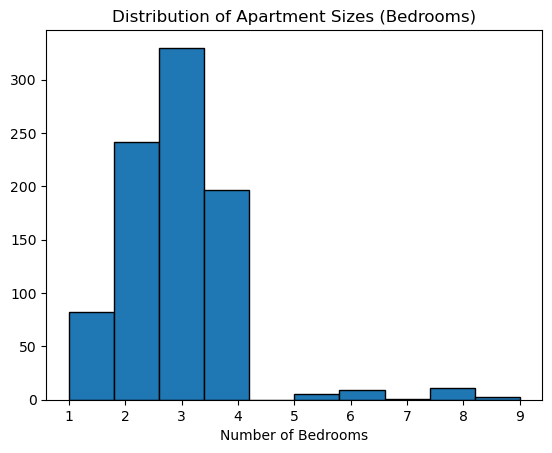

count    880.000000
mean       2.892045
std        1.195719
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        9.000000
Name: bedrooms, dtype: float64

In [7]:
# Explore apartment sizes
plt.hist(df["bedrooms"], bins=10, edgecolor="black")
plt.xlabel("Number of Bedrooms")
plt.title("Distribution of Apartment Sizes (Bedrooms)")
plt.show()

df["bedrooms"].describe()

In [9]:
# Remove bedroom outliers
low, high = df["bedrooms"].quantile([0.1, 0.9])
print(f"Keeping bedrooms between {low} and {high}")

Keeping bedrooms between 2.0 and 4.0


#### Scatter: Price vs Bedrooms

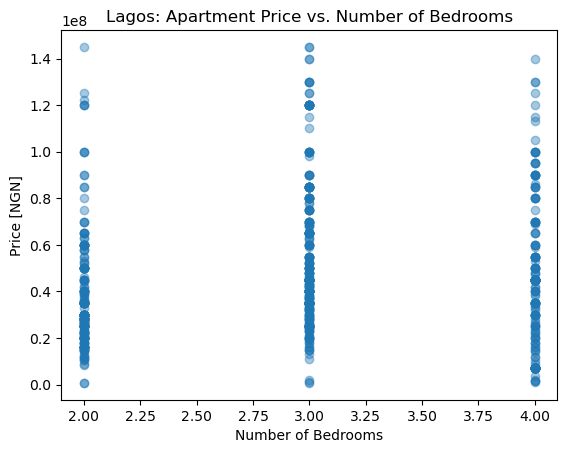

In [11]:
plt.scatter(x=df["bedrooms"], y=df["price"], alpha=0.4)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price [NGN]")
plt.title("Lagos: Apartment Price vs. Number of Bedrooms")
plt.show()

#### Split: feature matrix and target vector

In [12]:
features = ["bedrooms"]
target = "price"

X_train = df[features]
y_train = df[target]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (769, 1)
y_train shape: (769,)


#### Baseline model

In [13]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)

mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
print("Mean apartment price: ₦{:,.0f}".format(y_mean))
print("Baseline MAE: ₦{:,.0f}".format(mae_baseline))

Mean apartment price: ₦46,068,713
Baseline MAE: ₦21,775,839


#### Baseline plot

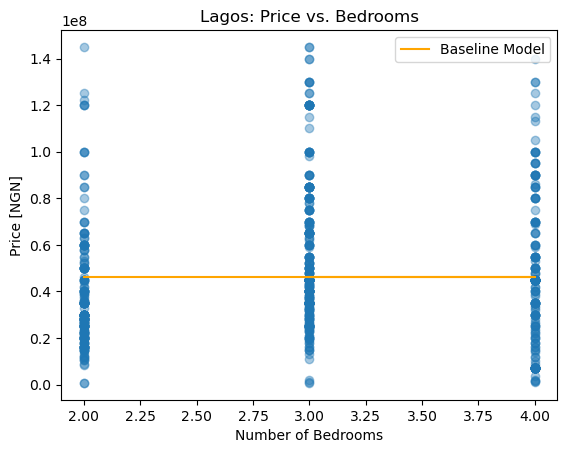

In [14]:
plt.scatter(X_train, y_train, alpha=0.4)
plt.plot(X_train, y_pred_baseline, color="orange", label="Baseline Model")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price [NGN]")
plt.title("Lagos: Price vs. Bedrooms")
plt.legend()
plt.show()

#### Linear regression model

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
check_is_fitted(model)
print("Model trained successfully.")

Model trained successfully.


In [16]:
# Evaluate on training data
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE: ₦{:,.0f}".format(mae_training))

Training MAE: ₦21,509,810


#### Communicate: equation + plot

apartment_price = 31845101.17 + 4835524.84 * bedrooms


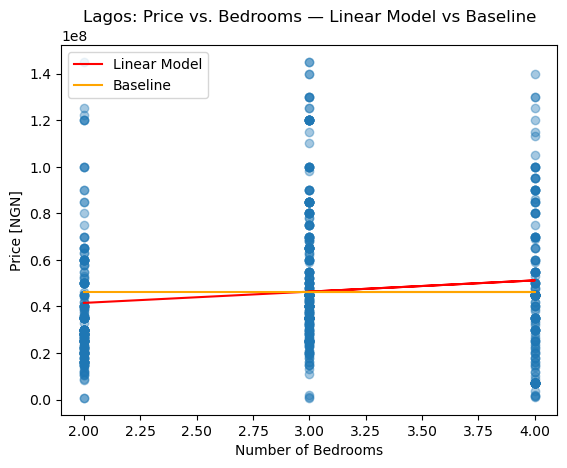

In [17]:
intercept = round(model.intercept_, 2)
coefficient = round(model.coef_[0], 2)

print(f"apartment_price = {intercept} + {coefficient} * bedrooms")

plt.scatter(X_train.values, y_train, alpha=0.4)
plt.plot(X_train.values, model.predict(X_train), color="red", label="Linear Model")
plt.plot(X_train.values, y_pred_baseline, color="orange", label="Baseline")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price [NGN]")
plt.title("Lagos: Price vs. Bedrooms — Linear Model vs Baseline")
plt.legend()
plt.show()

So far, the simplest possible predictive model - one that uses only the number of bedrooms to estimate apartment price in Lagos is built and tested. The baseline model, which blindly predicts the mean price for every apartment, gave a reference point to beat. The linear regression model improved on that baseline, confirming that bedroom count carries real price signal. However, the improvement was modest, which is expected - a single feature like bedrooms is a rough proxy for value. It tells us nothing about where in Lagos the apartment sits, which in a city as economically varied as Lagos, matters enormously.
This limitation is the natural motivation for the next section, where geographic location is added as an additional feature to the model.